# Fixed-Temperature MCMC for Noisy Graph Alignment

*Posterior sampling, node-wise correspondence probabilities, and uncertainty.*

This notebook implements the **fixed-temperature Metropolis–Hastings** part of the project:
a Markov chain whose stationary distribution is the alignment posterior

$$p_\beta(\pi \mid A,B)\;\propto\;\exp\big(\beta\,S(\pi)\big),
\qquad S(\pi)=\underbrace{\sum_{i<j}A_{ij}B_{\pi(i)\pi(j)}}_{\text{edge overlap}}
\;+\;\lambda\underbrace{\Big(-\sum_i\big|d_A(i)-d_B(\pi(i))\big|\Big)}_{\text{degree similarity}}.$$

The proposal swaps the images of two vertices, $\pi'(u)=\pi(v),\ \pi'(v)=\pi(u)$. It preserves the
permutation constraint and is symmetric, so the acceptance probability is
$\alpha=\min\{1,\exp(\beta(S(\pi')-S(\pi)))\}$.

**What it produces**
1. Score / best-so-far / accuracy traces and acceptance rate (§5).
2. Posterior marginal matrix $\widehat P_{ia}=\frac1M\sum_m \mathbf 1\{\pi^{(m)}(i)=a\}$ as a heatmap (§6).
3. Multiple-chain / restart diagnostics for mixing and multimodality (§7).
4. Calibration + selective matching: accuracy vs. coverage (§8).
5. Accuracy-vs-noise sweep against the random / degree baselines from the manifest (§9).

**Conventions** (matching `data/.../README.txt`): `pi[i] = a` means vertex `i` in `A` maps to `a` in `B`,
and `B_aligned = B[np.ix_(pi, pi)]`. `pi_true` / `B_clean` are used **only** for evaluation.

> **One thing worth knowing up front.** A single fixed-temperature swap chain is a good *sampler*
> (great for uncertainty) but a mediocre *optimizer*: it often locks into a local mode. The cure used
> here is **random restarts** — running several independent chains and pooling them. This is exactly
> the regime that motivates the annealing / parallel-tempering part of the project.

## 0. Imports & global config

In [1]:
import os
import time
from dataclasses import dataclass
from typing import Optional, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment

plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)


@dataclass
class MCMCConfig:
    beta: float = 2.0          # inverse temperature. ~2 works well for edge-overlap on these graphs;
                               #   too low -> random walk (never climbs), too high -> freezes in a mode.
    lam: float = 0.0           # weight of the degree-similarity term (0 = pure edge overlap)
    num_iters: int = 20_000
    burn_in: int = 5_000
    sample_every: int = 10     # thinning for collected posterior samples

cfg = MCMCConfig()
print(cfg)

MCMCConfig(beta=2.0, lam=0.0, num_iters=20000, burn_in=5000, sample_every=10)


## 1. Load the benchmark

Point `DATA_DIR` at the `er_benchmark_v2_500` folder you unzipped from `data.zip`.
The cell tries a few common locations automatically.

In [3]:
CANDIDATE_DIRS = [
    "data/er_benchmark_v2_500",
    "er_benchmark_v2_500",
    "./data/er_benchmark_v2_500",
    os.path.expanduser("~/data/er_benchmark_v2_500"),
]
DATA_DIR = next((d for d in CANDIDATE_DIRS if os.path.isdir(d)), None)
if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the benchmark folder. Set DATA_DIR manually to the path of "
        "'er_benchmark_v2_500' (the folder containing the .npz files + manifest.csv)."
    )
print("DATA_DIR =", DATA_DIR)

manifest = pd.read_csv(os.path.join(DATA_DIR, "manifest.csv"))
print(f"{len(manifest)} instances")
print("n     :", sorted(manifest.n.unique()))
print("p     :", sorted(manifest.p.unique()))
print("noise :", sorted(manifest.noise.unique()))
manifest.head(3)

DATA_DIR = data/er_benchmark_v2_500
500 instances
n     : [np.int64(30), np.int64(50)]
p     : [np.float64(0.15), np.float64(0.3)]
noise : [np.float64(0.0), np.float64(0.05), np.float64(0.1), np.float64(0.2), np.float64(0.3)]


,filename,path,n,p,noise,noise_model,seed_id,generation_seed,density_A,density_B,...,num_edges_B,true_score,true_accuracy,degree_score,degree_accuracy,degree_cost,random_score_mean,random_score_std,random_accuracy_mean,random_accuracy_std
0,er_n30_p015_eps000_seed000_resample.npz,data\er_benchmark_v2_500\er_n30_p015_eps000_se...,30,0.15,0.0,resample,0,1315000,0.160920,0.160920,...,70,70.0,1.0,18.0,0.366667,0.0,11.52,2.927388,0.036667,0.033500
1,er_n30_p015_eps000_seed001_resample.npz,data\er_benchmark_v2_500\er_n30_p015_eps000_se...,30,0.15,0.0,resample,1,1315001,0.156322,0.156322,...,68,68.0,1.0,29.0,0.433333,0.0,10.58,2.530534,0.035333,0.029371
2,er_n30_p015_eps000_seed002_resample.npz,data\er_benchmark_v2_500\er_n30_p015_eps000_se...,30,0.15,0.0,resample,2,1315002,0.147126,0.147126,...,64,64.0,1.0,13.0,0.133333,0.0,9.70,2.247221,0.039333,0.036932


In [4]:
@dataclass
class Instance:
    A: np.ndarray
    B: np.ndarray
    pi_true: np.ndarray
    n: int
    p: float
    noise: float
    seed_id: int
    filename: str


def load_instance(filename: str) -> Instance:
    d = np.load(os.path.join(DATA_DIR, filename), allow_pickle=True)
    return Instance(
        A=d["A"].astype(np.int64),
        B=d["B"].astype(np.int64),
        pi_true=d["pi_true"].astype(np.int64),
        n=int(d["n"]), p=float(d["p"]), noise=float(d["noise"]),
        seed_id=int(d["seed_id"]), filename=filename,
    )


def find_instances(n=None, p=None, noise=None, seed_id=None) -> pd.DataFrame:
    m = manifest
    if n      is not None: m = m[m.n == n]
    if p      is not None: m = m[np.isclose(m.p, p)]
    if noise  is not None: m = m[np.isclose(m.noise, noise)]
    if seed_id is not None: m = m[m.seed_id == seed_id]
    return m


def manifest_row(filename: str) -> pd.Series:
    return manifest.loc[manifest.filename == filename].iloc[0]

## 2. Scoring & accuracy

Self-contained versions of the score functions, identical in convention to the generator code.
`total_score` is used once at chain start; the chain itself uses the incremental delta below.

In [5]:
def is_valid_perm(pi: np.ndarray) -> bool:
    return np.array_equal(np.sort(pi), np.arange(len(pi)))


def edge_overlap_score(A, B, pi) -> float:
    B_aligned = B[np.ix_(pi, pi)]
    return float(np.sum(np.triu(A * B_aligned, k=1)))


def degree_node_score(A, B, pi) -> float:
    dA = A.sum(axis=1); dB = B.sum(axis=1)
    return float(-np.sum(np.abs(dA - dB[pi])))


def total_score(A, B, pi, lam=0.0) -> float:
    return edge_overlap_score(A, B, pi) + lam * degree_node_score(A, B, pi)


def alignment_accuracy(pi_hat, pi_true) -> float:
    return float(np.mean(pi_hat == pi_true))

## 3. Incremental score delta for a swap proposal

Swapping the images at positions $u,v$ only touches terms involving $u$ or $v$. For the
edge-overlap part this gives an exact $O(n)$ update:

$$\Delta S_{\text{edge}}=\sum_{k\neq u,v}\big(A_{uk}-A_{vk}\big)\big(B_{b\,\pi(k)}-B_{a\,\pi(k)}\big),
\qquad a=\pi(u),\ b=\pi(v).$$

The degree term changes only at positions $u,v$. Using the delta instead of recomputing the full
$O(n^2)$ score is what keeps long chains over many instances cheap.

In [6]:
def swap_delta(A, B, pi, degA, degB, u, v, lam=0.0) -> float:
    '''Exact change in total_score when the images of positions u and v are swapped.'''
    a = pi[u]; b = pi[v]
    dA = (A[u] - A[v]).astype(np.float64)      # length-n
    dB = (B[b][pi] - B[a][pi]).astype(np.float64)
    dA[u] = 0.0; dA[v] = 0.0                    # exclude k = u, v
    d_edge = float(dA @ dB)
    if lam != 0.0:
        d_node = ((abs(degA[u] - degB[a]) + abs(degA[v] - degB[b]))
                  - (abs(degA[u] - degB[b]) + abs(degA[v] - degB[a])))
        return d_edge + lam * d_node
    return d_edge

**Validation** — the delta must equal the full recomputation for random swaps (any `lam`).

In [7]:
def _validate_delta(filename, trials=2000, lam=0.7, seed=0):
    inst = load_instance(filename)
    A, B, n = inst.A, inst.B, inst.n
    degA, degB = A.sum(1), B.sum(1)
    r = np.random.default_rng(seed)
    pi = r.permutation(n)
    max_err = 0.0
    for _ in range(trials):
        u, v = r.choice(n, size=2, replace=False)
        s_old = total_score(A, B, pi, lam=lam)
        d_pred = swap_delta(A, B, pi, degA, degB, u, v, lam=lam)
        pi2 = pi.copy(); pi2[u], pi2[v] = pi[v], pi[u]
        s_new = total_score(A, B, pi2, lam=lam)
        max_err = max(max_err, abs((s_new - s_old) - d_pred))
        pi = pi2
    return max_err

err = _validate_delta(manifest.filename.iloc[0])
print(f"max |delta_pred - delta_true| = {err:.2e}")
assert err < 1e-6, "Incremental delta does not match full score!"
print("Incremental delta verified.")

max |delta_pred - delta_true| = 5.77e-15
Incremental delta verified.


## 4. The fixed-temperature MCMC sampler

One Metropolis–Hastings step: pick two distinct positions $u\neq v$, compute $\Delta S$ for swapping
their images, accept with probability $\min\{1,\exp(\beta\Delta S)\}$. Since the chain accepts
deterministically when $\Delta S\ge 0$, we only ever exponentiate non-positive numbers — no overflow.
After burn-in we thin by `sample_every` and accumulate the marginal counts $\widehat P_{ia}$.

In [8]:
@dataclass
class MCMCResult:
    P: np.ndarray                 # (n, n) posterior marginals  P[i, a]
    samples: np.ndarray           # (M, n) thinned post-burn-in samples
    best_pi: np.ndarray           # highest-scoring permutation seen (MAP estimate from this chain)
    best_score: float
    acceptance_rate: float
    score_trace: np.ndarray
    best_trace: np.ndarray
    accept_trace: np.ndarray      # 1 if the step at iter t was accepted
    acc_trace: Optional[np.ndarray]   # accuracy vs pi_true (diagnostic only)
    beta: float
    lam: float


def run_mcmc(A, B, beta, lam=0.0, num_iters=20_000, burn_in=5_000,
             sample_every=10, pi_init=None, rng=None, pi_true=None) -> MCMCResult:
    rng = rng if rng is not None else np.random.default_rng()
    A = A.astype(np.float64); B = B.astype(np.float64)
    n = A.shape[0]
    degA = A.sum(1); degB = B.sum(1)

    pi = rng.permutation(n) if pi_init is None else pi_init.copy()
    cur = total_score(A, B, pi, lam=lam)
    best_pi, best_score = pi.copy(), cur

    score_trace  = np.empty(num_iters)
    best_trace   = np.empty(num_iters)
    accept_trace = np.zeros(num_iters)
    acc_trace    = np.empty(num_iters) if pi_true is not None else None

    counts = np.zeros((n, n))
    rows = np.arange(n)
    samples: List[np.ndarray] = []
    n_accept = 0

    for t in range(num_iters):
        u = int(rng.integers(n))               # two distinct positions, cheaply
        v = int(rng.integers(n - 1))
        if v >= u:
            v += 1

        d = swap_delta(A, B, pi, degA, degB, u, v, lam=lam)
        if d >= 0.0 or rng.random() < np.exp(beta * d):
            pi[u], pi[v] = pi[v], pi[u]
            cur += d
            n_accept += 1
            accept_trace[t] = 1.0
            if cur > best_score:
                best_score = cur
                best_pi = pi.copy()

        score_trace[t] = cur
        best_trace[t]  = best_score
        if acc_trace is not None:
            acc_trace[t] = np.mean(pi == pi_true)

        if t >= burn_in and (t % sample_every == 0):
            counts[rows, pi] += 1.0
            samples.append(pi.copy())

    M = max(len(samples), 1)
    return MCMCResult(
        P=counts / M, samples=np.array(samples), best_pi=best_pi, best_score=float(best_score),
        acceptance_rate=n_accept / num_iters, score_trace=score_trace, best_trace=best_trace,
        accept_trace=accept_trace, acc_trace=acc_trace, beta=beta, lam=lam,
    )


@dataclass
class MultiStartResult:
    chains: List[MCMCResult]
    P: np.ndarray                 # marginals pooled over all chains' post-burn-in samples
    best_pi: np.ndarray           # global best across chains (multi-start MAP)
    best_score: float


def run_multistart(A, B, beta, lam=0.0, n_starts=6, num_iters=20_000, burn_in=5_000,
                   sample_every=10, base_seed=0, pi_true=None) -> MultiStartResult:
    '''Independent restarts: pool samples for a robust posterior, keep the global best for MAP.'''
    n = A.shape[0]
    chains, all_samples = [], []
    best_pi, best_score = None, -np.inf
    for k in range(n_starts):
        c = run_mcmc(A, B, beta, lam=lam, num_iters=num_iters, burn_in=burn_in,
                     sample_every=sample_every, rng=np.random.default_rng(base_seed + k),
                     pi_true=pi_true)
        chains.append(c)
        all_samples.append(c.samples)
        if c.best_score > best_score:
            best_score, best_pi = c.best_score, c.best_pi.copy()
    pooled = np.vstack(all_samples)
    counts = np.zeros((n, n)); rows = np.arange(n)
    for s in pooled:
        counts[rows, s] += 1.0
    return MultiStartResult(chains=chains, P=counts / len(pooled),
                            best_pi=best_pi, best_score=float(best_score))


def marginal_to_permutation(P):
    '''Project soft marginals to the single best *valid* permutation (Hungarian on -log P).'''
    cost = -np.log(P + 1e-12)
    r, c = linear_sum_assignment(cost)
    pi = np.empty(P.shape[0], dtype=int); pi[r] = c
    return pi

## 5. Single-chain run + diagnostics

We use a moderately noisy instance and run **one** chain so we can see the raw behaviour: the score
trace, the best-so-far envelope, the running acceptance rate, and (for diagnostics only) the accuracy
of the current state against `pi_true`.

In [9]:
DEMO = find_instances(n=30, p=0.3, noise=0.1, seed_id=2).filename.iloc[0]
inst = load_instance(DEMO)
row  = manifest_row(DEMO)
print(f"Instance: {DEMO}")
print(f"n={inst.n}  p={inst.p}  noise={inst.noise}")
print(f"true_score={row.true_score:.0f}   degree_acc={row.degree_accuracy:.3f}   "
      f"random_acc(mean)={row.random_accuracy_mean:.3f}")

t0 = time.time()
res = run_mcmc(inst.A, inst.B, beta=cfg.beta, lam=cfg.lam,
               num_iters=cfg.num_iters, burn_in=cfg.burn_in, sample_every=cfg.sample_every,
               rng=np.random.default_rng(0), pi_true=inst.pi_true)
print(f"\nran {cfg.num_iters} iters in {time.time()-t0:.2f}s   acceptance={res.acceptance_rate:.3f}")
print(f"this chain: best score = {res.best_score:.0f}   "
      f"best-perm accuracy = {alignment_accuracy(res.best_pi, inst.pi_true):.3f}")
print("(A single chain may or may not find the mode -- that is the point of section 7.)")

Instance: er_n30_p030_eps010_seed002_resample.npz
n=30  p=0.3  noise=0.1
true_score=129   degree_acc=0.100   random_acc(mean)=0.033

ran 20000 iters in 0.23s   acceptance=0.038
this chain: best score = 129   best-perm accuracy = 1.000
(A single chain may or may not find the mode -- that is the point of section 7.)


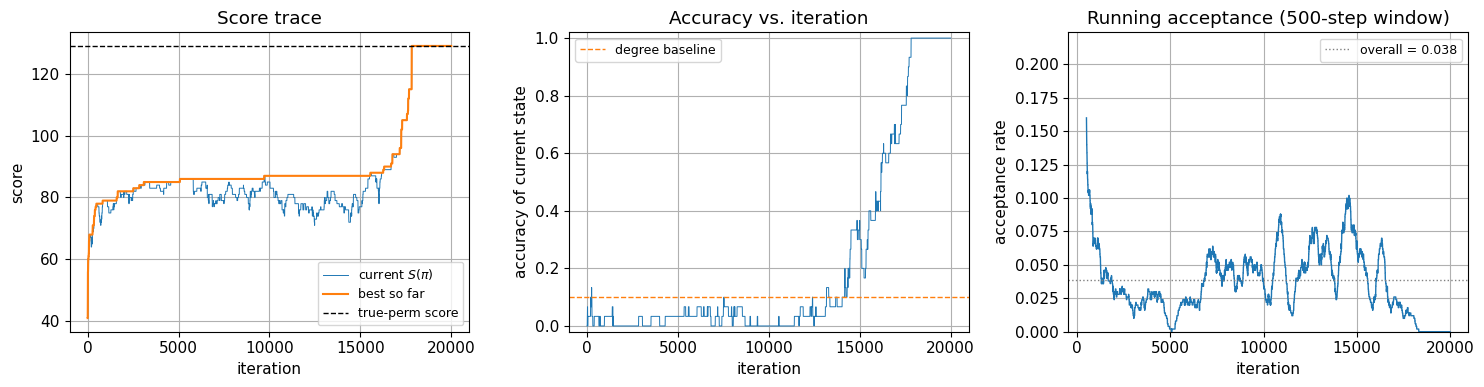

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].plot(res.score_trace, lw=0.7, label="current $S(\\pi)$")
ax[0].plot(res.best_trace, lw=1.5, label="best so far")
ax[0].axhline(row.true_score, ls="--", color="k", lw=1, label="true-perm score")
ax[0].set(xlabel="iteration", ylabel="score", title="Score trace")
ax[0].legend(fontsize=9)

ax[1].plot(res.acc_trace, lw=0.7)
ax[1].axhline(row.degree_accuracy, ls="--", color="C1", lw=1, label="degree baseline")
ax[1].set(xlabel="iteration", ylabel="accuracy of current state",
          title="Accuracy vs. iteration", ylim=(-0.02, 1.02))
ax[1].legend(fontsize=9)

window = 500
run_acc = np.convolve(res.accept_trace, np.ones(window) / window, mode="valid")
ax[2].plot(np.arange(len(run_acc)) + window, run_acc, lw=1)
ax[2].axhline(res.acceptance_rate, ls=":", color="gray", lw=1,
              label=f"overall = {res.acceptance_rate:.3f}")
ax[2].set(xlabel="iteration", ylabel="acceptance rate",
          title=f"Running acceptance ({window}-step window)")
ax[2].set_ylim(0, min(1.0, max(0.1, float(run_acc.max()) * 1.4)))
ax[2].legend(fontsize=9)

plt.tight_layout(); plt.show()

## 6. Multi-start run & posterior marginals $\widehat P$

Now we run several restarts and **pool** their post-burn-in samples. This both (a) gives a far more
reliable MAP and (b) yields a better posterior estimate. $\widehat P_{ia}$ is the posterior
probability that vertex $i$ of $A$ matches vertex $a$ of $B$; reordering the columns by `pi_true`
puts the *correct* answer on the diagonal, so a bright diagonal = confident & correct.

multi-start MAP (best score) accuracy : 1.000
marginal argmax accuracy (may be invalid): 0.933  (valid perm: False)
marginal Hungarian-projected accuracy : 1.000


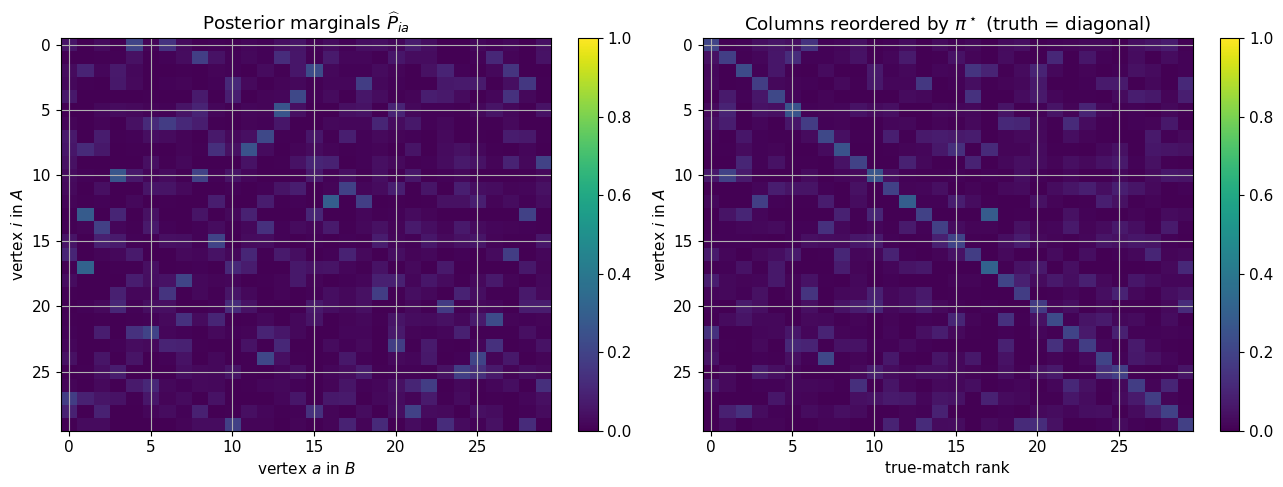

In [11]:
ms = run_multistart(inst.A, inst.B, beta=cfg.beta, lam=cfg.lam, n_starts=6,
                    num_iters=cfg.num_iters, burn_in=cfg.burn_in, sample_every=cfg.sample_every,
                    base_seed=100, pi_true=inst.pi_true)

P = ms.P
pi_marg = P.argmax(axis=1)                 # per-vertex argmax (proposal's definition)
conf    = P.max(axis=1)                     # per-vertex confidence c_i
pi_proj = marginal_to_permutation(P)        # valid-permutation projection

print(f"multi-start MAP (best score) accuracy : {alignment_accuracy(ms.best_pi, inst.pi_true):.3f}")
print(f"marginal argmax accuracy (may be invalid): {np.mean(pi_marg == inst.pi_true):.3f}  "
      f"(valid perm: {is_valid_perm(pi_marg)})")
print(f"marginal Hungarian-projected accuracy : {alignment_accuracy(pi_proj, inst.pi_true):.3f}")

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
im0 = ax[0].imshow(P, aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax[0].set(title="Posterior marginals $\\widehat P_{ia}$", xlabel="vertex $a$ in $B$",
          ylabel="vertex $i$ in $A$")
fig.colorbar(im0, ax=ax[0], fraction=0.046)

im1 = ax[1].imshow(P[:, inst.pi_true], aspect="auto", cmap="viridis", vmin=0, vmax=1)
ax[1].set(title="Columns reordered by $\\pi^\\star$ (truth = diagonal)",
          xlabel="true-match rank", ylabel="vertex $i$ in $A$")
fig.colorbar(im1, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

## 7. Mixing & multimodality across restarts

If independent chains agree, the posterior is effectively unimodal and well mixed. Different score
plateaus and disagreeing marginals are the signature of multimodality — the motivation for annealing /
parallel tempering. The per-chain best scores below typically split into "found the mode" vs. "stuck".

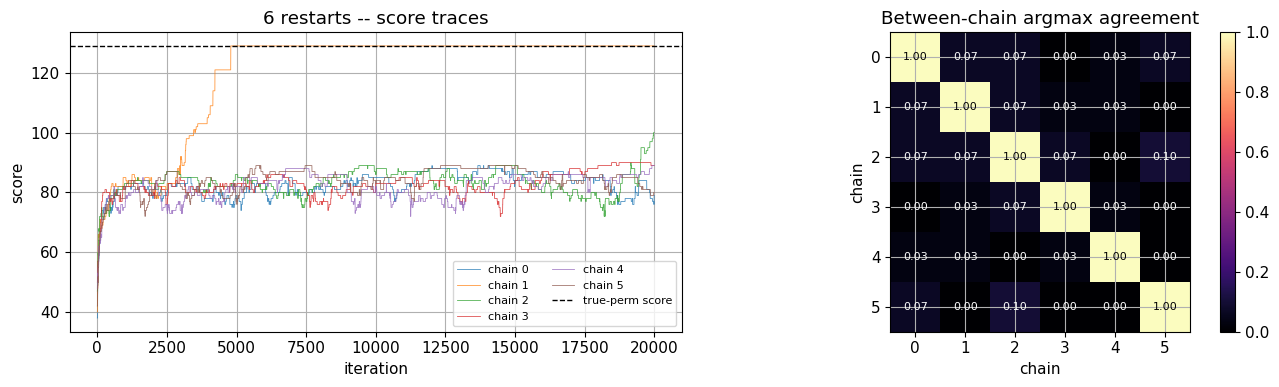

per-chain best score   : [89, 129, 100, 90, 89, 89]
per-chain best accuracy: [0.067, 1.0, 0.733, 0.033, 0.2, 0.0]


In [12]:
chains = ms.chains
K = len(chains)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for k, c in enumerate(chains):
    ax[0].plot(c.score_trace, lw=0.6, alpha=0.8, label=f"chain {k}")
ax[0].axhline(row.true_score, ls="--", color="k", lw=1, label="true-perm score")
ax[0].set(xlabel="iteration", ylabel="score", title=f"{K} restarts -- score traces")
ax[0].legend(fontsize=8, ncol=2)

argmaxes = np.array([c.P.argmax(1) for c in chains])
agree = np.array([[np.mean(argmaxes[i] == argmaxes[j]) for j in range(K)] for i in range(K)])
im = ax[1].imshow(agree, vmin=0, vmax=1, cmap="magma")
ax[1].set(title="Between-chain argmax agreement", xlabel="chain", ylabel="chain",
          xticks=range(K), yticks=range(K))
for i in range(K):
    for j in range(K):
        ax[1].text(j, i, f"{agree[i,j]:.2f}", ha="center", va="center",
                   color="white" if agree[i, j] < 0.6 else "black", fontsize=8)
fig.colorbar(im, ax=ax[1], fraction=0.046)
plt.tight_layout(); plt.show()

print("per-chain best score   :", [int(c.best_score) for c in chains])
print("per-chain best accuracy:", [round(alignment_accuracy(c.best_pi, inst.pi_true), 3) for c in chains])

## 8. Calibration & selective matching

Per-vertex confidence is $c_i=\max_a\widehat P_{ia}$. A useful posterior is **calibrated**
(high confidence $\Rightarrow$ high accuracy) and supports **selective matching**: keep only vertices
with $c_i\ge\tau$, trading coverage for accuracy. Both use the pooled marginals from §6.

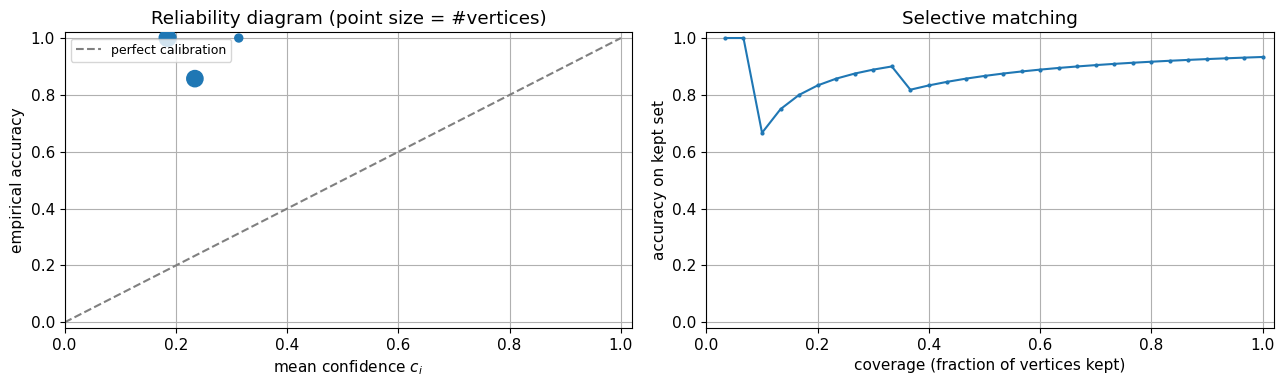

In [13]:
correct = (pi_marg == inst.pi_true).astype(float)

# Reliability diagram: bin vertices by confidence, measure empirical accuracy per bin.
edges = np.linspace(0, 1, 11)
idx = np.clip(np.digitize(conf, edges) - 1, 0, len(edges) - 2)
bc, ba, bn = [], [], []
for b in range(len(edges) - 1):
    m = idx == b
    if m.any():
        bc.append(conf[m].mean()); ba.append(correct[m].mean()); bn.append(int(m.sum()))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot([0, 1], [0, 1], ls="--", color="gray", label="perfect calibration")
ax[0].scatter(bc, ba, s=[25 + 8*c for c in bn], zorder=3)
ax[0].set(xlabel="mean confidence $c_i$", ylabel="empirical accuracy",
          title="Reliability diagram (point size = #vertices)", xlim=(0, 1.02), ylim=(-0.02, 1.02))
ax[0].legend(fontsize=9)

# Coverage-accuracy: sort by confidence, sweep the threshold.
order = np.argsort(-conf)
sel_acc  = np.cumsum(correct[order]) / np.arange(1, inst.n + 1)
coverage = np.arange(1, inst.n + 1) / inst.n
ax[1].plot(coverage, sel_acc, marker=".", ms=4)
ax[1].set(xlabel="coverage (fraction of vertices kept)", ylabel="accuracy on kept set",
          title="Selective matching", xlim=(0, 1.02), ylim=(-0.02, 1.02))
plt.tight_layout(); plt.show()

## 9. Accuracy vs. noise (vs. baselines)

Run multi-start MCMC across the full noise grid for a fixed $(n,p)$, averaging over several seeds, and
compare the MCMC MAP and marginal-projection accuracy against the random / degree baselines stored in
the manifest. Lower `SWEEP_SEEDS` / `SWEEP_ITERS` / `SWEEP_STARTS` for a quick pass, raise for the report.

In [14]:
SWEEP_N, SWEEP_P = 30, 0.30
SWEEP_SEEDS  = 5            # seed_ids 0..SWEEP_SEEDS-1 per noise level
SWEEP_STARTS = 4            # restarts per instance
SWEEP_ITERS  = 12_000
SWEEP_BURN   = 4_000

noise_levels = sorted(manifest.noise.unique())
records = []
t0 = time.time()
for noise in noise_levels:
    rows = find_instances(n=SWEEP_N, p=SWEEP_P, noise=noise)
    rows = rows[rows.seed_id < SWEEP_SEEDS]
    for _, r in rows.iterrows():
        ins = load_instance(r.filename)
        out = run_multistart(ins.A, ins.B, beta=cfg.beta, lam=cfg.lam, n_starts=SWEEP_STARTS,
                             num_iters=SWEEP_ITERS, burn_in=SWEEP_BURN,
                             sample_every=cfg.sample_every, base_seed=7_000 + 13 * int(r.seed_id))
        records.append(dict(
            noise=noise,
            map_acc=alignment_accuracy(out.best_pi, ins.pi_true),
            marg_acc=alignment_accuracy(marginal_to_permutation(out.P), ins.pi_true),
            degree_acc=float(r.degree_accuracy),
            random_acc=float(r.random_accuracy_mean),
        ))
print(f"sweep done in {time.time()-t0:.1f}s  ({len(records)} instances x {SWEEP_STARTS} restarts)")

df = pd.DataFrame(records)
summary = df.groupby("noise").mean(numeric_only=True)
sem     = df.groupby("noise").sem(numeric_only=True)
summary

sweep done in 8.3s  (25 instances x 4 restarts)


,map_acc,marg_acc,degree_acc,random_acc
noise,,,,
0.00,0.806667,0.726667,0.353333,0.032933
0.05,0.440000,0.340000,0.173333,0.030667
0.10,0.046667,0.066667,0.186667,0.029867
0.20,0.360000,0.273333,0.120000,0.039867
0.30,0.300000,0.126667,0.093333,0.035733


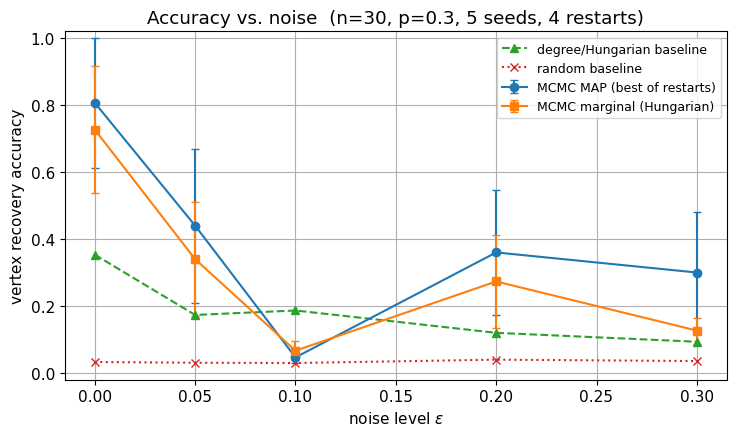

In [15]:
x = summary.index.values
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.errorbar(x, summary.map_acc,  yerr=sem.map_acc,  marker="o", capsize=3, label="MCMC MAP (best of restarts)")
ax.errorbar(x, summary.marg_acc, yerr=sem.marg_acc, marker="s", capsize=3, label="MCMC marginal (Hungarian)")
ax.plot(x, summary.degree_acc, marker="^", ls="--", label="degree/Hungarian baseline")
ax.plot(x, summary.random_acc, marker="x", ls=":",  label="random baseline")
ax.set(xlabel="noise level $\\epsilon$", ylabel="vertex recovery accuracy",
       title=f"Accuracy vs. noise  (n={SWEEP_N}, p={SWEEP_P}, {SWEEP_SEEDS} seeds, {SWEEP_STARTS} restarts)",
       ylim=(-0.02, 1.02))
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 10. Notes & easy extensions

- **`beta`** trades exploration for concentration. Edge-overlap scores are small integers here, so the
  useful range is roughly $\beta\in[1.5, 3]$; sweep it and watch the acceptance rate. Too small → the
  chain random-walks and never climbs; too large → it freezes in the first local mode it finds.
- **`lam`** turns on the degree-similarity unary term; useful when the edge signal is weak (high noise).
- **Restarts matter.** A single fixed-temperature chain is a sampler, not an optimizer; `run_multistart`
  is the cheap, proposal-sanctioned fix. The split in per-chain best scores in §7 is the multimodality
  the project is about.
- Larger / denser instances (`n=50`, `p=0.3`) and symmetric graphs stress mixing the most — rerun §6–§7
  there and watch between-chain agreement drop.
- The annealing / parallel-tempering pieces reuse `swap_delta` directly: anneal $\beta_1<\dots<\beta_T$
  for MAP, or run several `run_mcmc` chains at different $\beta$ with periodic state-exchange moves.